In [1]:
import yaml
import torch
import numpy as np
from einops import rearrange
from matplotlib import pyplot as plt
from typing import Sequence

### Visualize Patch Tumor Distribution

In [2]:
rootdir = '/home/ca550013/Master-Thesis/Projects/BraTS3DDiff'

In [3]:
from src.datasets.patch_tumor_classify_diffusion_datamodule_new_new import BraTSDataModule

In [17]:
with open(f"{rootdir}/configs/data/brats23_patch_tumor_classify_diffusion_new.yaml") as f:
    cfg = yaml.safe_load(f)
cfg.pop('_target_')
cfg['data_dir'] = f"{rootdir}/data/BraTS-Data/BraTS2023-GLI"
cfg['batch_size'] = 1
cfg['patch_sizes'] = [16, 32]
datamodule = BraTSDataModule(**cfg)

train_data = datamodule.data_train
test_data = datamodule.data_test
val_data = datamodule.data_val


/home/ca550013/Miniconda3-New/envs/bratseg/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [ ]:
data = val_data.__getitem__(5)
data.keys()

In [ ]:
data['patch_tumor_vol_fracs']['32'].shape

Plotting tools

In [18]:
from matplotlib import pyplot as plt

def compute_histogram(patch_vol_fracs, nbins=10, res=16):
    '''
    Compute histogram of tumor vol fracs of patches in an image.
    Count zero vol patches and non zero patches separately
    '''
    #patch_vol_fracs: (1,8,8,8) tensor
    patch_vol_fracs = patch_vol_fracs.view(1, -1)

    non_zero_vol_fracs = patch_vol_fracs[patch_vol_fracs > 0]
    hist = torch.histogram(input=non_zero_vol_fracs, bins=nbins, range=(non_zero_vol_fracs.min().item(),1))

    num_zero_patches = (patch_vol_fracs == 0).sum().item()
    bin_counts = torch.cat((torch.tensor([num_zero_patches]), hist.hist)).numpy()
    bin_edges = torch.cat((torch.tensor([0.0]), hist.bin_edges)).numpy()
    #print('bin_edges', bin_edges)
    bin_labels = ["0 (zero)"] + [
        f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}" for i in range(1, len(bin_edges) - 1)
    ]

    num_non_zero_patches = non_zero_vol_fracs.shape[0]
    counts = np.array([num_zero_patches, num_non_zero_patches])
    labels = ['Zero Vol Patches', 'Non-Zero Vol Patches']

    return {f'hist_{res}':(bin_counts, bin_labels), f'hist2_{res}':(counts, labels)}


def plot_hist(ax, bin_counts, bin_labels, res=16):
    ax.bar(range(len(bin_counts)), bin_counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(bin_labels)))
    ax.set_xticklabels(bin_labels, rotation=45, ha="right")
    ax.set_xlabel("Volume Fractions")
    ax.set_ylabel("Number of Patches")
    ax.set_title(f"Histogram of Patch Tumor Volume Fractions\nPatch size={res}")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax

def plot_hist_binary(ax, counts, labels, res=16):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Number of Patches")
    ax.set_title(f"Distribution of non-zero and zero volume patches\nPatch size={res}")
    # Add Bar Labels
    for c in ax.containers:
        ax.bar_label(c)
    return ax

def transform_imgs(data: dict, depth:int=None, label_regions=['WT','TC', 'ET'], patch_sizes:list=None, key=''):
    #Transforms a dict of 3D images to 2D
    new_data = {}
    img_key, label_key, label_key_ = [f"{key}{x}" for x in ['image', 'mask', "mask_labels"]]
    
    image = data[img_key]
    if depth is None:
        depth = image.shape[-1] // 2
    new_data[img_key] = image[0,:,:,depth]

    new_data[label_key_] = data[label_key_][0,:,:,depth]

    if label_regions is not None:
        label = data[label_key][:,:,:,depth]
        labels = {f"{key}label_{label_regions[i]}": label[i,:,:] for i in range(len(label_regions))}
        new_data.update(labels)

    if ('patch_tumor_labels' in data.keys()) and (patch_sizes is not None):
        for patch_size in patch_sizes:
            patch_labels = data['patch_tumor_labels'][patch_size]
            new_data[f'patch_labels_{patch_size}'] = patch_labels[0,:,:,patch_labels.shape[-1] // 2]

    if ('patch_tumor_vol_fracs' in data.keys()) and (patch_sizes is not None):
        for patch_size in patch_sizes:
            patch_labels = data['patch_tumor_vol_fracs'][patch_size]
            new_data[f'patch_vol_frac_{patch_size}'] = patch_labels[0,:,:,patch_labels.shape[-1] // 2]

    return new_data

def imshows(ims: list[dict]):
    nrow = len(ims)
    ncol = len(ims[0])
    fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 4, nrow * 5), facecolor="white")
    for i, im_dict in enumerate(ims):
        for j, (title, im) in enumerate(im_dict.items()):
            if isinstance(im, torch.Tensor):
                im = im.detach().cpu().numpy()
            if len(ims) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]
            #ax.grid(snap=False)
            if title.startswith('hist_'):
                res = title.split('_')[-1]
                ax = plot_hist(ax, im[0], im[1], res=res)
            elif title.startswith('hist2_'):
                res = title.split('_')[-1]
                ax = plot_hist_binary(ax, im[0], im[1], res=res)
            else:
                ax.set_title(f"{title}\n{im.shape}")
                im_show = ax.imshow(im)
                fig.colorbar(im_show, ax=ax)
    plt.tight_layout()


In [ ]:
to_imshow = []
for idx in np.random.randint(0, len(val_data), size=2):
    data_ = val_data.__getitem__(idx)
    data_.pop('patch_tumor_labels')
    hist_16 = compute_histogram(data_['patch_tumor_vol_fracs']['16'], res=16)
    hist_32 = compute_histogram(data_['patch_tumor_vol_fracs']['32'], res=32)
    data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
    data_1.update(hist_16)
    data_1.update(hist_32)

    to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
to_imshow = []
idx = 212

hist_16 = compute_histogram(data_['patch_tumor_vol_fracs']['16'], res=16)
hist_32 = compute_histogram(data_['patch_tumor_vol_fracs']['32'], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

Compute patch tumor vol distributions of all images in dataset \
And compute some statistics


In [19]:

hist_data = {'hist_16':[], 'hist2_16':[], 'hist_32':[], 'hist2_32':[]}
patch_tumor_vol_fracs = {'16':[], '32': []}
for idx in range(len(val_data)):
    data = val_data.__getitem__(idx)
    patch_tumor_vol_fracs['16'].append(data['patch_tumor_vol_fracs']['16'])
    hist_16 = compute_histogram(data['patch_tumor_vol_fracs']['16'], res=16)
    hist_data['hist_16'].append(hist_16['hist_16'][0])
    hist_data['hist2_16'].append(hist_16['hist2_16'][0])
    patch_tumor_vol_fracs['32'].append(data['patch_tumor_vol_fracs']['32'])
    hist_32 = compute_histogram(data['patch_tumor_vol_fracs']['32'], res=32)
    hist_data['hist_32'].append(hist_32['hist_32'][0])
    hist_data['hist2_32'].append(hist_32['hist2_32'][0])


mean_hist = {}
median_hist = {}
max_hist = {}
min_hist = {}

for key in hist_data.keys():
    hist_data[key] = np.array(hist_data[key])
    mean_hist[key] = np.mean(hist_data[key], axis=0)
    median_hist[key] = np.median(hist_data[key], axis=0)
    max_hist[key] = np.max(hist_data[key], axis=0)
    min_hist[key] = np.min(hist_data[key], axis=0)

print('Mean Statistics')
print(mean_hist)
print('Median Statistics')
print(median_hist)
print('Max Statistics')
print(max_hist)
print('Min Statistics')
print(min_hist)


Mean Statistics
{'hist_16': array([444.73462  ,  26.061539 ,   8.115385 ,   5.6615386,   4.523077 ,
         3.7346153,   3.35     ,   3.146154 ,   2.6923077,   2.896154 ,
         7.084615 ], dtype=float32), 'hist2_16': array([444.73461538,  67.26538462]), 'hist_32': array([47.765385  ,  9.180769  ,  2.2038462 ,  1.45      ,  0.99615383,
        0.7923077 ,  0.5730769 ,  0.38846153,  0.27307692,  0.2423077 ,
        0.13461539], dtype=float32), 'hist2_32': array([47.76538462, 16.23461538])}
Median Statistics
{'hist_16': array([447. ,  25.5,   8. ,   5. ,   4. ,   3. ,   3. ,   3. ,   2. ,
         3. ,   5.5], dtype=float32), 'hist2_16': array([447.,  65.]), 'hist_32': array([48.,  9.,  2.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.],
      dtype=float32), 'hist2_32': array([48., 16.])}
Max Statistics
{'hist_16': array([508., 104.,  32.,  30.,  14.,  14.,  12.,  15.,  11.,  10.,  31.],
      dtype=float32), 'hist2_16': array([508, 211]), 'hist_32': array([63., 33.,  8.,  7.,  5.,  5.,  4.

### Observation:
<ins>16x16x16 patches (n=512):</ins> \
On **average**, there are 445 non-tumor patches and 67 tumor patches \
The **maximum** of tumor patches found in an image is 213

<ins>32x32x32 patches (n=64):</ins> \
On **average**, there are 48 non-tumor patches and 16 tumor patches \
The **maximum** of tumor patches found in an image is 48

### Patch Selection during Training

##### Diverse strategy: Biased towards tumor patches+All samples have a non-zero prob of getting selected
Sample C patches from N patches based on their weights. Add a small weight to Non-tumor patches so that have a non-zero probability of getting selected. Mix of weighted+uniform sampling to inrease diversity?


In [20]:
#Check number of images for which there are more than N tumor patches
key = 'hist2_16'
N=150
num_imgs = (hist_data[key][:,1] > N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data[key][:,1] >= N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data[key][i])


num number of images for which there are more than 150 tumor patches = 2
Image indices = [128 212]
Non-Tumor vs Tumor Patch counts of these images:
 [[339 173]
 [301 211]]


In [ ]:
#Filter images wrt numof tumor patches
N=30
num_imgs = (hist_data['hist2_32'][:,1] == N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_32'][:,1] == N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_32'][i])

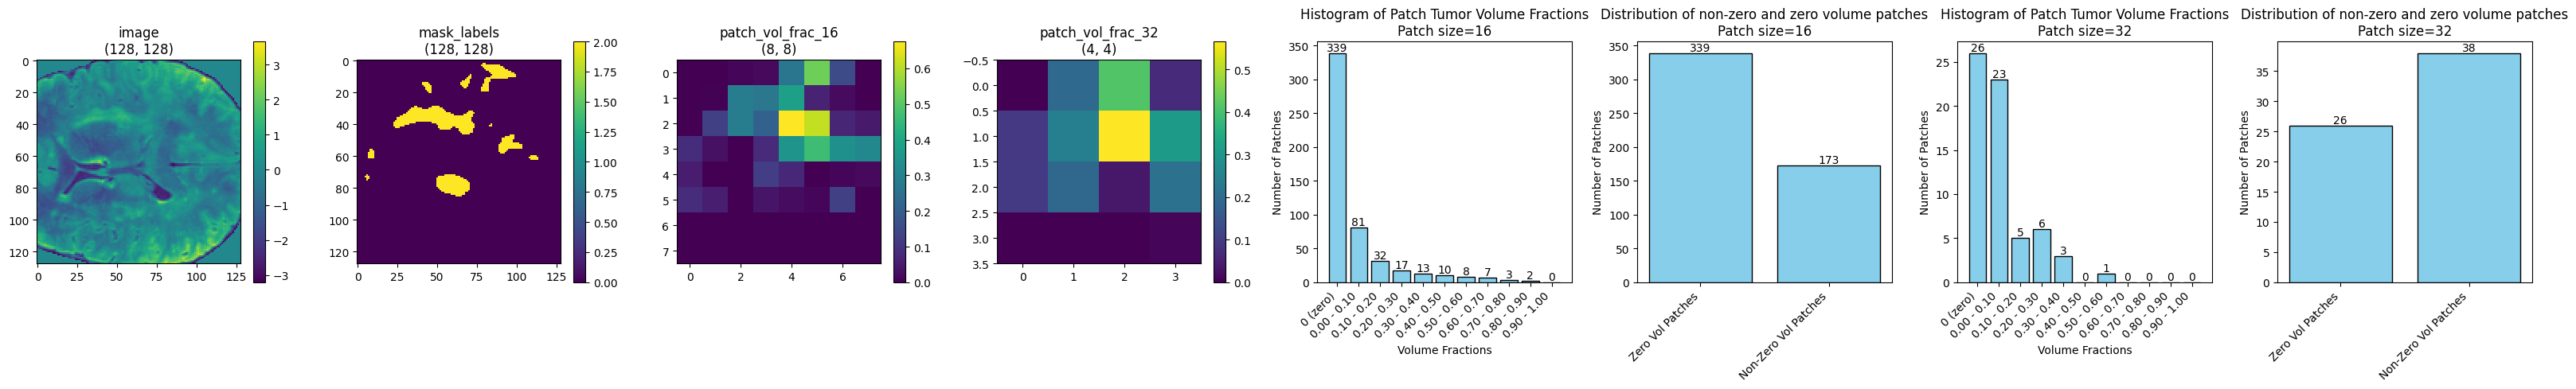

In [21]:
#Visualize these images
idx = 128 
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

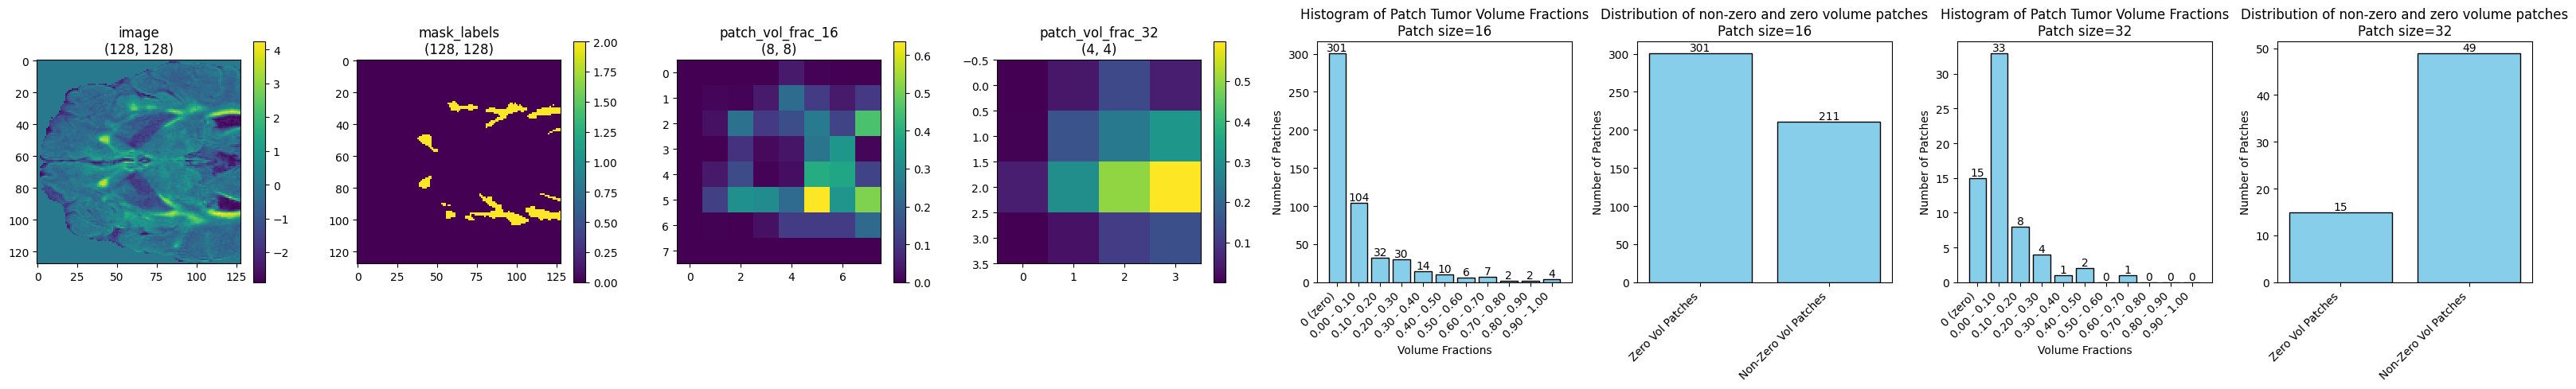

In [22]:
#Visualize these images
idx = 212
to_imshow = []
data_ = val_data.__getitem__(idx)
data_.pop('patch_tumor_labels')
hist_16 = compute_histogram(patch_tumor_vol_fracs['16'][idx], res=16)
hist_32 = compute_histogram(patch_tumor_vol_fracs['32'][idx], res=32)
data_1 = transform_imgs(data_, label_regions=None, patch_sizes=['16', '32'])
data_1.update(hist_16)
data_1.update(hist_32)

to_imshow.append(data_1)

imshows(to_imshow)

In [ ]:
idx = 212
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
all_patch_vols=torch.sort(all_patch_vols).values
print('All patches vol fracs sorted' ,all_patch_vols)
print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
all_patch_vols=all_patch_vols.squeeze(dim=0)

#### Patch Sampling
- Sampling should be biased towards tumor patches, and patches with higher tumor vols
- Sampling strategy should also cover the entire space of patches, ie mix of tumor and non tumor patches \
        No patch should go unseen. Model should see all the patches at least once during training

Idea: Add a small weight *eps* to all the patches so that the non-tumor patches also have > 0 probability of getting sampled \
*Higher the added weight, closer the sampling gets to uniform sampling*

wt of a patch = patch_tumor_vol_frac + eps

*eps scheduling*: Instead of adding a fixed weight, add **higher** weights in the **beginning** of training, so that model sees both tumor and non-tumor patches; \
As training progresses, **decreases** the added weights, so that the sampling becomes more biased towards the tumor patches

#### Comparison between different different values of eps, and fixed / dynamic eps
Goal: 
- Good patch coverage, ie after sampling for N rounds, all patches should be seen, and, 
- Biased sampling, ie Patches with higher tumor vols should be selected more often

Validation scheme:
Sample 32 out of 64 patches of an image N times, and after N rounds, count how many times each patch was sampled 

The patch distribution should be biased towards higher tumor vol patches, moreover,  non-tumor patches should also have non-zero counts. 

To see which sampling strategy captures both of these characteristics, compute similarity between the evaluated patch counts distribution and a baseline uniform and weighted patch distribution



In [ ]:
#Filter images wrt numof tumor patches
N=32
num_imgs = (hist_data['hist2_32'][:,1] == N).sum()
print(f'num number of images for which there are more than {N} tumor patches = {num_imgs}')
i, = np.where(hist_data['hist2_32'][:,1] == N)
print(f'Image indices = {i}')
print('Non-Tumor vs Tumor Patch counts of these images:\n', hist_data['hist2_32'][i])

In [ ]:
def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,end_eps=0.0,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps - ((start_eps-end_eps)*(i/N_use)) 
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='blue')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=256  #num of patches to sample out of 64 patches

base_epss = [0.1,0.01,0.001,1e-4, 1e-10, 1e-20, 0]

use_fracs = [1.0]
schedules = ['linear']
start_epss = [1.0, 0.1,0.05,0.01,0.001,1e-4]
end_epss = [1e-10, 1e-20, 0]

#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]
#for idx in range(len(val_data)):
image_idxs = [128, 212]
key = 'hist2_16'
for idx in image_idxs:
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs['16'][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print(all_patch_vols.nonzero())
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    nrow, ncol = 1, len(base_epss)
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)
        ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\n mean_score={mean_score:.5f}")

    fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for end_eps in end_epss:
                nrow, ncol = 1, len(start_epss)
                fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white") 
                fig1, ax1 = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")

                for i,start_eps in enumerate(start_epss):
                    counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,end_eps=end_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                    counts_p = counts/counts.sum()

                    kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                    kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                    score_1 = 10*(kl_wt_1+kl_uni_1)
                    kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                    kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                    score_2 = kl_wt_2+kl_uni_2
                    mean_score = 0.5*(score_1+score_2)

                    ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}, end_eps={end_eps}\n kl_wt_1={kl_wt_1:.5f}, kl_uni_1={kl_uni_1:.5f},\n kl_wt_2={kl_wt_2:.5f}, kl_uni_2={kl_uni_2:.5f}\nmean_score={mean_score:.5f}")

                    ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}, end_eps={end_eps}")

                fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps), use_frac={use_frac}. Image id={idx}, num tumor patches={num_tumor}")
                fig.tight_layout()
                fig1.suptitle('Schedule of added weights (eps)')
                fig1.tight_layout()

Processing image 128
Non-Tumor and Tumor Patch Counts [339 173]
All patches vol fracs sorted metatensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0

In [29]:
1/(16**3)

0.000244140625

In [ ]:
np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()

Compute scores for every image and compute mean to see which *use_frac* and *start_eps* combination performs best 

Also compare between *fixed eps* and *dynamic eps* (schedule based)

In [ ]:

def count_samples(wts,eps=0,k=32,N=1000):
    #count the number of times an item was sampled,
    # after sampling k out of len(wts) items N times
    counts = torch.zeros_like(wts)
    wts_ = wts + eps

    for i in range(N):
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts

def count_samples_dyn_eps(wts,start_eps=0.01,schedule='linear',k=32,N=1000,use_frac=0.8):
    counts = torch.zeros_like(wts)
    epss = []
    ps=[]
    for i in range(N):
        N_use = N*use_frac
        if i <= N_use - 1:
            if schedule == 'linear':
                eps = start_eps*(1-(i/N_use))
            elif schedule == 'cosine':
                eps = start_eps*np.cos((np.pi*i)/(2*N_use))
        epss.append(eps)
        wts_ = wts + eps
        sampled_indices = torch.multinomial(wts_,k)
        counts[sampled_indices] += 1
    return counts, epss

def plot_patch_counts(ax,counts,title):
    ax.bar(range(len(counts)), counts, color='skyblue', edgecolor='black')
    ax.set_ylabel("Num of times patch is sampled")
    ax.set_title(title)
    return ax

def plot_(ax,eps,title):
    ax.plot(eps)
    ax.set_title(title)
    return ax

N=300 #num of sampling rounds
k=256  #num of patches to sample out of 64 patches

base_epss = [20,0.1,0.01,0.001,1e-4,1e-20]
use_fracs = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3]
schedules = ['linear','cosine']
start_epss_1 = np.around(np.linspace(0.1, 0.01, 10), decimals=2).tolist()
start_epss_2 = np.around(np.linspace(1.0, 0.2, 9), decimals=2).tolist()
start_epss = start_epss_1 + start_epss_2 +[0.001, 1e-4]

print(start_epss)
#Plot a few image use cases with varying num tumor patches = 4, 10, 20, 30, 35, 49
#image_idxs = [222, 18, 114, 137, 206, 212]

fixed_eps_df_rows = []
dyn_eps_df_rows = []
key = 'hist2_16'
for idx in range(len(val_data)):
    print(f'Processing image {idx}')
    print('Non-Tumor and Tumor Patch Counts',hist_data[key][idx])
    num_tumor = hist_data[key][idx][1]
    #get patch tumor vols of an image and reshape into 1D tensor
    all_patch_vols = patch_tumor_vol_fracs['16'][idx].view(1,-1)
    all_patch_vols=torch.sort(all_patch_vols).values
    print('All patches vol fracs sorted' ,all_patch_vols)
    print('Tumor Patch indices' ,all_patch_vols.nonzero()[:,1])
    all_patch_vols=all_patch_vols.squeeze(dim=0)

    #uniform and weighted sampling with varying eps
    cmp_counts_weighted = count_samples(all_patch_vols,eps=base_epss[-1],k=k,N=N)
    cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
    cmp_counts_uniform = count_samples(all_patch_vols,eps=base_epss[0],k=k,N=N)
    cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()

    uniform_wts = torch.ones_like(all_patch_vols)/len(all_patch_vols)
    tumor_wts = all_patch_vols/all_patch_vols.sum()

    #Fixed eps
    #fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 6, nrow * 5), facecolor="white")
    for i,eps in enumerate(base_epss):
        fixed_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
        fixed_eps_df_row['eps'] = eps
        counts = count_samples(all_patch_vols,eps=eps,k=k,N=N)
        counts_p = counts/counts.sum()
        kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
        kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
        score_1 = 10*(kl_wt_1+kl_uni_1)
    
        kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
        kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
        score_2 = kl_wt_2+kl_uni_2
        mean_score = 0.5*(score_1+score_2)

        fixed_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                        'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
        fixed_eps_df_rows.append(fixed_eps_df_row)

        #ax[i] = plot_patch_counts(ax[i],counts,title=f"eps={eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")

    #fig.suptitle(f"Patch coverage after sampling for {N} rounds (Fixed eps). Image id={idx}, num tumor patches={num_tumor}")
    #fig.tight_layout()

    #Dynamic p and eps
    for use_frac in use_fracs:
        for schedule in schedules:
            for i,start_eps in enumerate(start_epss):
                dyn_eps_df_row = {'image_id':idx, 'num_tumor_patches':num_tumor}
                dyn_eps_df_row.update({'schedule':schedule, 'use_frac':use_frac, 'start_eps':start_eps})
                
                counts, epss_= count_samples_dyn_eps(all_patch_vols,start_eps=start_eps,schedule=schedule,k=k,N=N,use_frac=use_frac)
                counts_p = counts/counts.sum()

                kl_wt_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_weighted_p).item()
                kl_uni_1 = torch.nn.functional.kl_div(counts_p.log(), cmp_counts_uniform_p).item()
                score_1 = 10*(kl_wt_1+kl_uni_1)
            
                kl_wt_2 = torch.nn.functional.kl_div(counts_p.log(), tumor_wts).item()
                kl_uni_2 = torch.nn.functional.kl_div(counts_p.log(), uniform_wts).item()
                score_2 = kl_wt_2+kl_uni_2
                mean_score = 0.5*(score_1+score_2)

                dyn_eps_df_row.update({'kl_wt_1':kl_wt_1,'kl_uni_1':kl_uni_1,'score_1':score_1, \
                                'kl_wt_2':kl_wt_2,'kl_uni_2':kl_uni_2,'score_2':score_2, 'mean_score':mean_score})
                dyn_eps_df_rows.append(dyn_eps_df_row)

                #ax[i] = plot_patch_counts(ax[i],counts,title=f"start_eps={start_eps}\nscore_1={score_1:.5f}, score_2={score_2:.5f}, score={mean_score:.5f}")
                #ax1[i] = plot_(ax1[i,], epss_,title=f"start_eps={start_eps}")

            #fig.suptitle(f"Patch coverage after sampling for {N} rounds ({schedule} eps), use_frac={use_frac}. Image id={idx}, num tumor patches={num_tumor}")
            #fig.tight_layout()
            #fig1.suptitle('Schedule of added weights (eps)')
            #fig1.tight_layout()

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')

In [ ]:
dyn_eps_df

In [214]:

import pandas as pd

fixed_eps_df = pd.DataFrame.from_dict(fixed_eps_df_rows)
dyn_eps_df = pd.DataFrame.from_dict(dyn_eps_df_rows)
dyn_eps_df.to_csv('dyn_eps_df_1.csv')
fixed_eps_df.to_csv('fixed_eps_df_1.csv')


In [4]:
rootdir

'/home/ca550013/Master-Thesis/Projects/BraTS3DDiff'

In [11]:
import pandas as pd
import os
dataroot = os.path.join(rootdir, 'results', 'results', 'patch_sampling_eps_schedule')
fixed_eps_df = pd.read_csv(os.path.join(dataroot, 'fixed_eps_df_16.csv'), index_col=0)
dyn_eps_df = pd.read_csv(os.path.join(dataroot, 'dyn_eps_df_16.csv'), index_col=0)

In [12]:
fixed_eps_df.head()

,image_id,num_tumor_patches,eps,kl_wt_1,kl_uni_1,score_1,kl_wt_2,kl_uni_2,score_2,mean_score
0,0,82,20.0000,0.000154,0.000007,0.001609,0.004552,0.000003,0.004555,0.003082
1,0,82,0.1000,0.000059,0.000064,0.001232,0.003328,0.000063,0.003391,0.002312
2,0,82,0.0100,0.000022,0.000105,0.001272,0.003249,0.000104,0.003353,0.002312
3,0,82,0.0010,0.000011,0.000126,0.001372,0.003243,0.000126,0.003369,0.002371
4,0,82,0.0001,0.000006,0.000133,0.001397,0.003243,0.000133,0.003376,0.002386


            eps   kl_wt_1  kl_uni_1   kl_wt_2  kl_uni_2   score_2  mean_score
0  1.000000e-20  0.000007  0.000115  0.003942  0.000114  0.004056    0.002638
1  1.000000e-04  0.000007  0.000114  0.003942  0.000113  0.004055    0.002632
2  1.000000e-03  0.000010  0.000105  0.003942  0.000104  0.004047    0.002603
3  1.000000e-02  0.000024  0.000086  0.003949  0.000085  0.004033    0.002565
4  1.000000e-01  0.000051  0.000051  0.004059  0.000050  0.004109    0.002567
5  2.000000e+01  0.000131  0.000007  0.005258  0.000003  0.005261    0.003319


<Axes: title={'center': 'Mean score vs eps'}, xlabel='eps'>

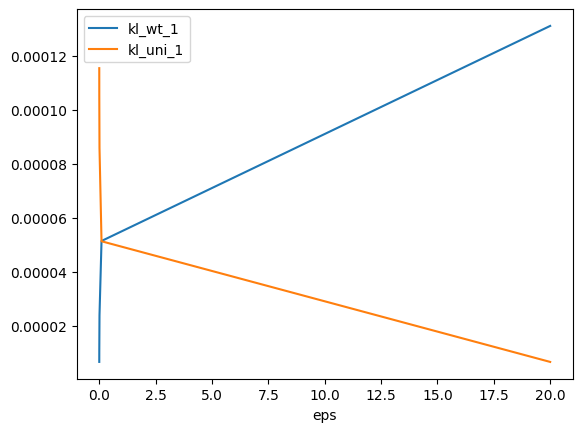

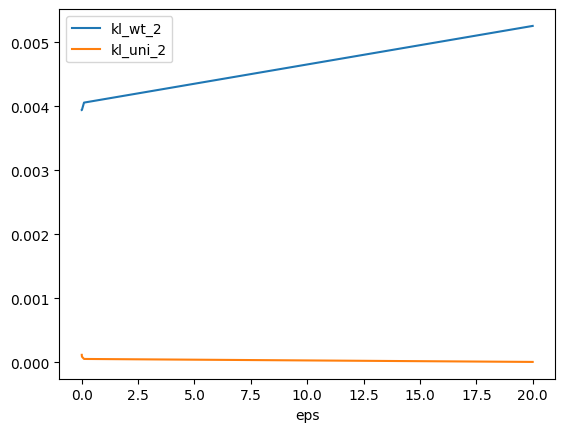

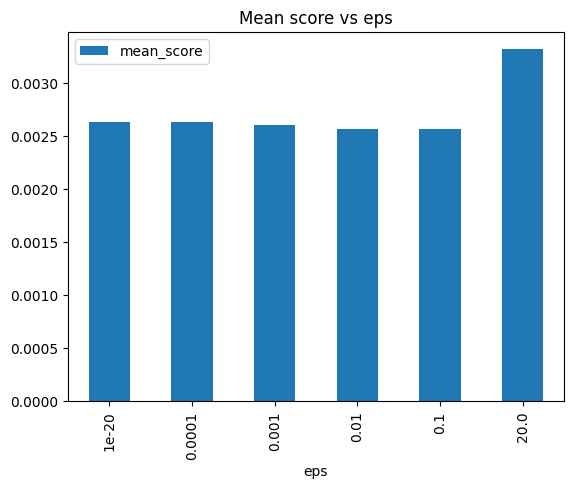

In [13]:
#find mean score for each eps 'kl_wt_2','kl_uni_2','score_2','mean_score'
fixed_eps_agg = fixed_eps_df.groupby(['eps'], as_index=False)[['kl_wt_1', 'kl_uni_1', 'kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print(fixed_eps_agg)
fixed_eps_agg[['eps', 'kl_wt_1', 'kl_uni_1']].set_index('eps').plot()
fixed_eps_agg[['eps', 'kl_wt_2', 'kl_uni_2']].set_index('eps').plot()
fixed_eps_agg[['eps', 'mean_score']].set_index('eps').plot(kind='bar', title='Mean score vs eps')


#Obs: As eps increases, patch distrbitution becomes close to uniform, so kl_uni decreases
## and if eps is small, patch distribution is more close to weighted distribution

In [ ]:
dyn_eps_df

In [14]:
import seaborn as sns


min score config:       use_frac  start_eps schedule   kl_wt_1  kl_uni_1   score_1   kl_wt_2  \
193       0.7        0.2   linear  0.000027  0.000064  0.000914  0.004021   

     kl_uni_2   score_2  mean_score  
193  0.000063  0.004084    0.002499  


<Axes: xlabel='num_tumor_patches'>

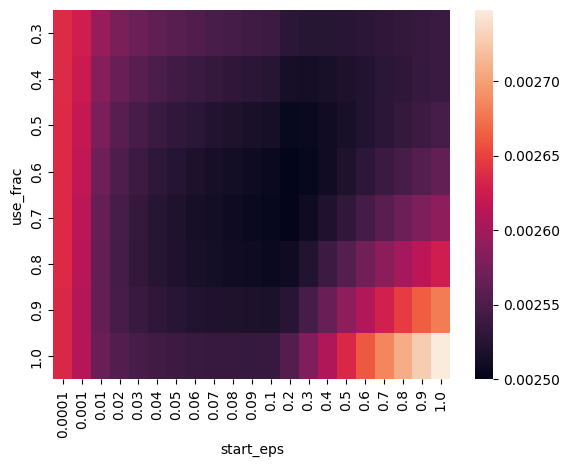

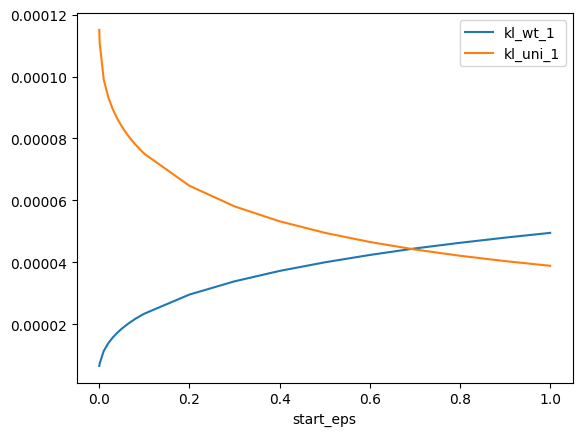

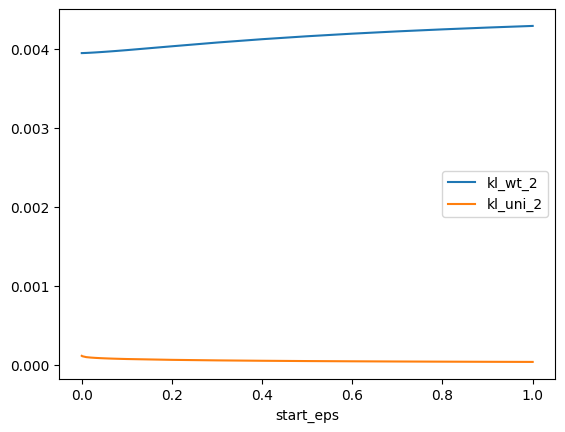

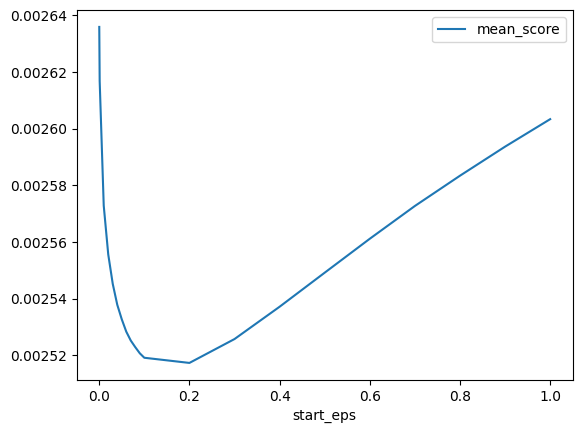

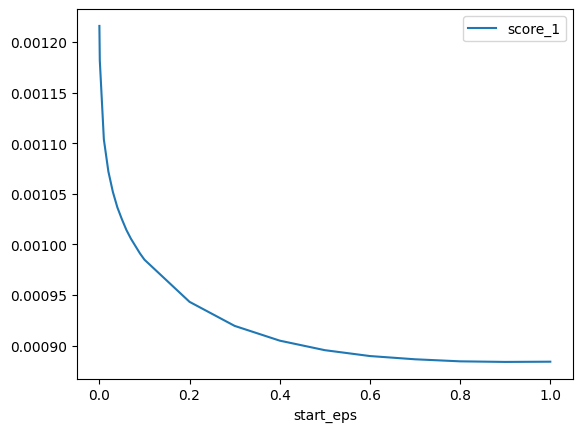

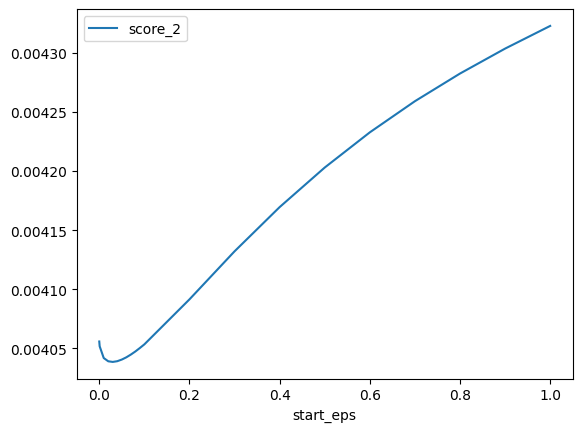

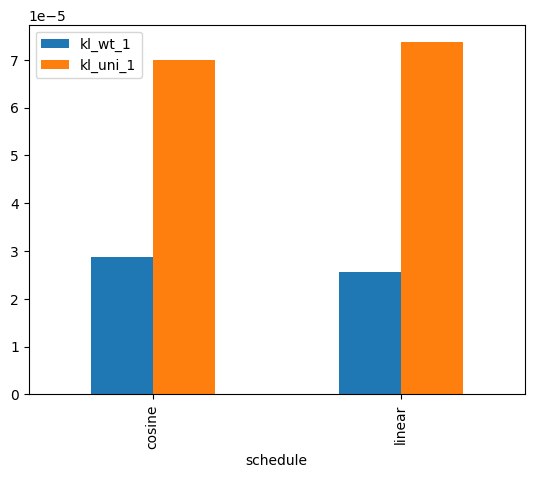

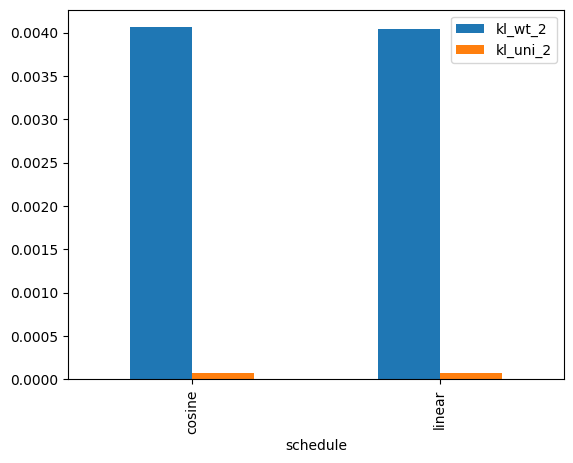

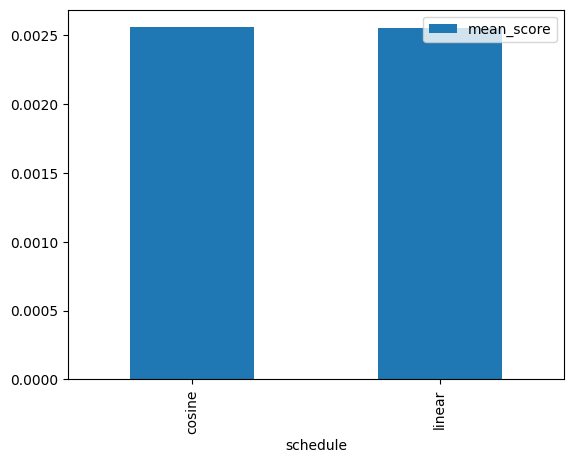

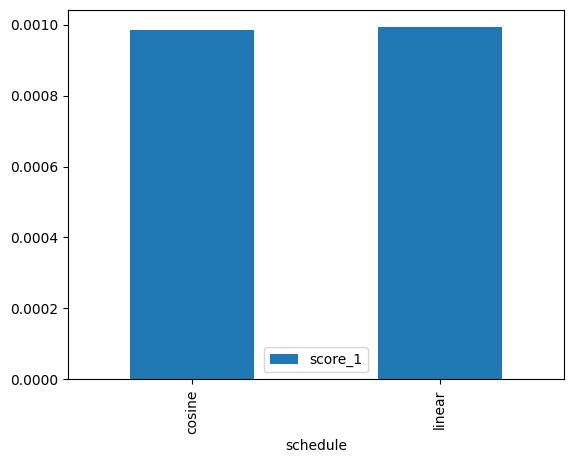

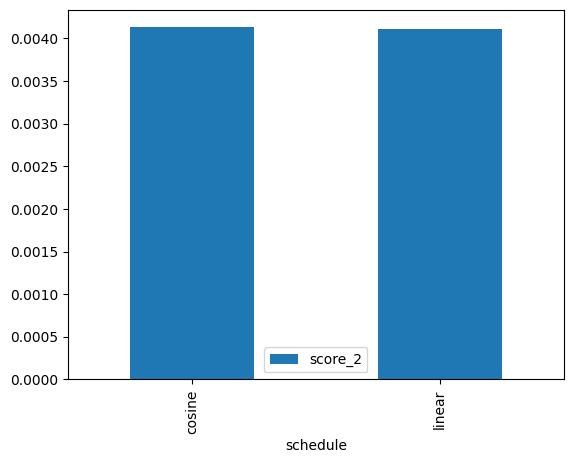

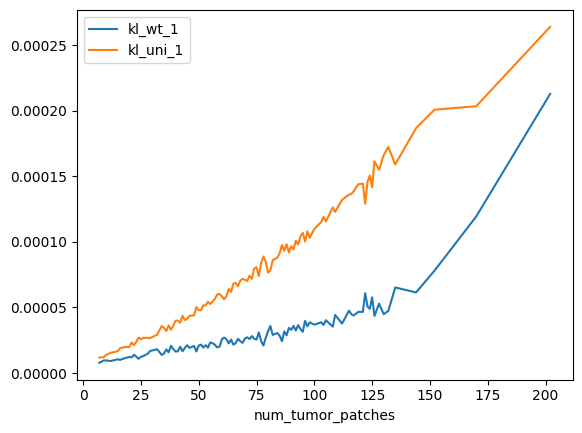

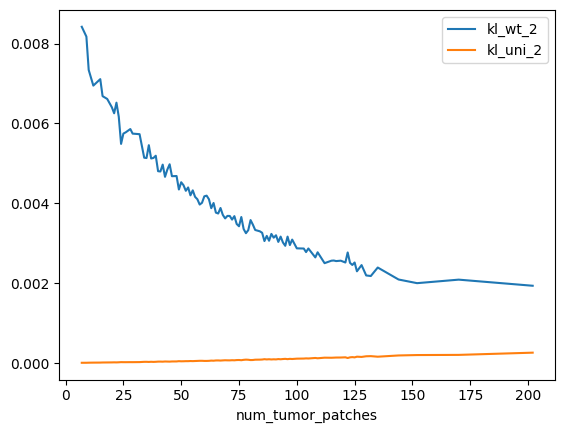

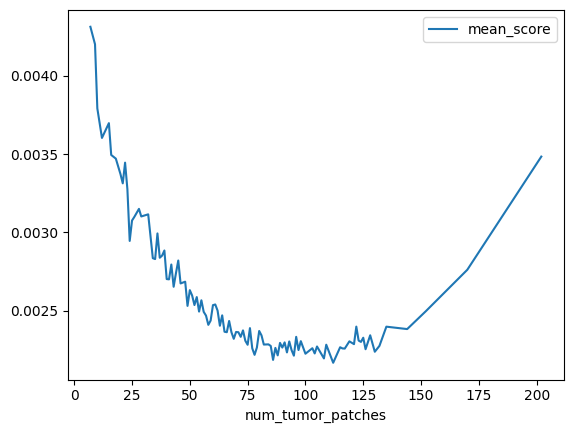

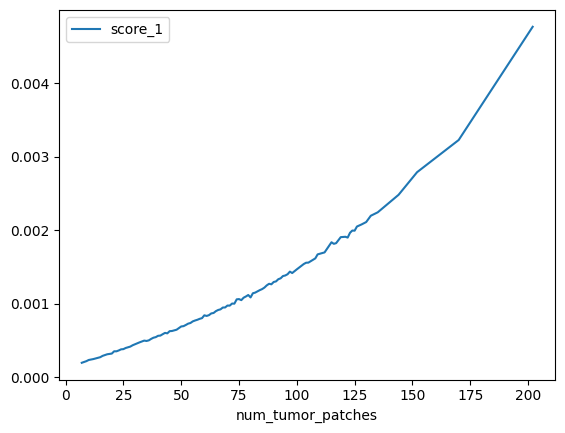

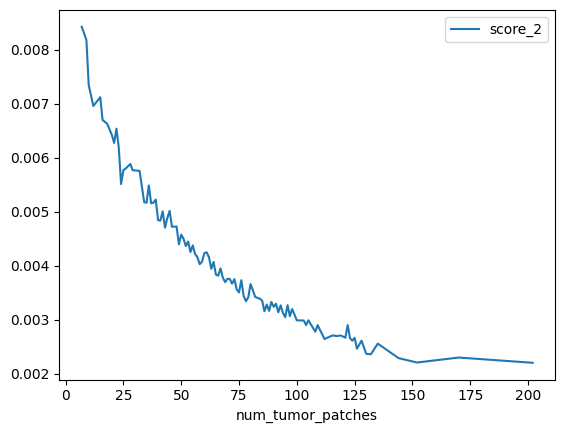

In [15]:
dyn_eps_all_agg_ = dyn_eps_df.groupby(['use_frac','start_eps','schedule'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
print('min score config: ', dyn_eps_all_agg_[dyn_eps_all_agg_['mean_score'] == dyn_eps_all_agg_['mean_score'].min()])

dyn_eps_all_agg= dyn_eps_df.groupby(['use_frac','start_eps'],  as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
sns.heatmap(dyn_eps_all_agg.pivot(index='use_frac',columns='start_eps',values='mean_score'))

dyn_eps_agg = dyn_eps_all_agg.groupby(['start_eps'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_eps_agg[['start_eps', 'kl_wt_1', 'kl_uni_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'kl_wt_2', 'kl_uni_2']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'mean_score']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_1']].set_index('start_eps').plot()
dyn_eps_agg[['start_eps', 'score_2']].set_index('start_eps').plot()

dyn_schedule_agg = dyn_eps_df.groupby(['schedule'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_schedule_agg[['schedule', 'kl_wt_1', 'kl_uni_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'kl_wt_2', 'kl_uni_2']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'mean_score']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_1']].set_index('schedule').plot(kind='bar')
dyn_schedule_agg[['schedule', 'score_2']].set_index('schedule').plot(kind='bar')

'''
dyn_use_agg = dyn_eps_all_agg.groupby(['use_frac'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_use_agg[['use_frac', 'kl_wt_1', 'kl_uni_1']].set_index('use_frac').plot()
dyn_use_agg[['use_frac', 'kl_wt_2', 'kl_uni_2']].set_index('use_frac').plot()
'''
dyn_num_tumor_agg = dyn_eps_df.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_num_tumor_agg[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()


In [ ]:
#Subset df on best config and plot num_tumor_patches vs scores
dyn_eps_df_sub = dyn_eps_df[(dyn_eps_df['use_frac'] == 0.7) & (dyn_eps_df['start_eps'] == 0.1)].reset_index(drop=True)
dyn_eps_df_sub_ =  dyn_eps_df_sub.groupby(['num_tumor_patches'], as_index=False)[['kl_wt_1', 'kl_uni_1','score_1','kl_wt_2','kl_uni_2','score_2','mean_score']].mean()

num_tumor_patches_counts=dyn_eps_df_sub['num_tumor_patches'].value_counts().to_frame()
dyn_eps_df_sub_ = dyn_eps_df_sub_.merge(num_tumor_patches_counts,on='num_tumor_patches')

dyn_eps_df_sub_[['num_tumor_patches', 'count']].set_index('num_tumor_patches').plot(title='Num of images with n tumor patches')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_1', 'kl_uni_1']].set_index('num_tumor_patches').plot(kind='bar')
dyn_eps_df_sub_[['num_tumor_patches', 'kl_wt_2', 'kl_uni_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_1']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'score_2']].set_index('num_tumor_patches').plot()
dyn_eps_df_sub_[['num_tumor_patches', 'mean_score']].set_index('num_tumor_patches').plot()


Obs: Mean score is the least in for images with the most common number of patches (=15/16)

Score_1 and score_2 are very complementary in nature

kl_wt_1 is high for n_tumor_patches = 28-32 as the patch counts are compared with the *eps=1e-20* basline counts. in this case, all the 30-32 tumor patches will be sampled most of the time as we are sampling 32 items

In [33]:
dyn_eps_df.to_csv('dyn_eps_df.csv')
fixed_eps_df.to_csv('fixed_eps_df.csv')

In [ ]:
all_patch_vols = patch_tumor_vol_fracs['32'][idx].view(1,-1)
torch.sort(all_patch_vols)

In [ ]:
import itertools

def ravel_index_(index, shape):
    """Ravel multi-dimensional indices to 1D index
    similar to np.ravel_multi_index
    Args:
        index (torch.tensor): indices in reversed order dn, ..., d1, with shape (..., n)
        shape (tuple): dn, ..., d1
    """
    index = torch.tensor(index, dtype=torch.int64)
    shape = torch.tensor((1,) + shape[::-1], dtype=torch.int64) # =(1, d1, d1*d2, ..., d1*...*dn)
    shape = torch.cumprod(shape, dim=0)[:-1].flip(0) # =(d1*...*dn-1, ..., d1*d2, d1, 1)
    index = (index * shape).sum(dim=-1) # (...,)
    return index


def get_16_idx_from_32_flat_idx(flat_idxs_32,x_16_shape,x_32_shape):
  assert len(x_16_shape) == len(x_32_shape)
  print('flat_idxs_32 ', flat_idxs_32)

  unravled_idxs_32 = torch.unravel_index(flat_idxs_32, x_32_shape)
  unravled_idxs_32_T = torch.stack(unravled_idxs_32, dim=0).T
  unravled_idxs_start_16 = unravled_idxs_32_T*torch.tensor([1,2,2,2])

  list(itertools.product([0, 1], repeat=3))
  offsets = list(itertools.product([0, 1], repeat=3))
  offsets = [[0]+list(offset) for offset in offsets]
  offsets = torch.tensor(offsets)
  print('offsets ', offsets)

  unraveled_idxs_all_16 = unravled_idxs_start_16.unsqueeze(1) + offsets
  unraveled_idxs_all_16 = unraveled_idxs_all_16.contiguous().view(-1,len(x_16_shape))

  flat_idxs_16 = ravel_index_(unraveled_idxs_all_16, x_16_shape)
  print('flat_idxs_16 ', flat_idxs_16)

  unraveled_idxs_all_16 = torch.unbind(unraveled_idxs_all_16, dim=1)
  return flat_idxs_16, unraveled_idxs_all_16


x_16 = torch.linspace(0, 1023, steps=1024).view(2,8,8,8)
x_32 = torch.linspace(0, 127, steps=128).view(2,4,4,4)
sampled_idxs_32 = torch.multinomial(torch.ones_like(x_32.flatten()),num_samples=32)

flat_idxs_16, unraveled_idxs_all_16 = get_16_idx_from_32_flat_idx(sampled_idxs_32,x_16.shape,x_32.shape)
test_raveled_idxs_16 = x_16[unraveled_idxs_all_16]
assert torch.all(flat_idxs_16 == test_raveled_idxs_16)


In [ ]:
patch_tumor_vol_fracs['16'][idx].shape

In [ ]:

idx = 34
N=300
k_32 = 32
k_16 = 256
eps= 0.001
all_patch_vols_16 = patch_tumor_vol_fracs['16'][idx].view(1,-1).squeeze(dim=0)
all_patch_vols_16_sorted_out=torch.sort(all_patch_vols_16)
all_patch_vols_16_sorted = all_patch_vols_16_sorted_out.values
sorted_indices_16 = all_patch_vols_16_sorted_out.indices
idx_mapping = torch.argsort(sorted_indices_16)
print('Tumor Patch indices' ,all_patch_vols_16_sorted.nonzero()[:,0])

cmp_counts_weighted = count_samples(all_patch_vols_16_sorted,eps=1e-20,k=k,N=N)
cmp_counts_weighted_p = cmp_counts_weighted/cmp_counts_weighted.sum()
cmp_counts_uniform = count_samples(all_patch_vols_16_sorted,eps=20,k=k,N=N)
cmp_counts_uniform_p = cmp_counts_uniform/cmp_counts_uniform.sum()
uniform_wts = torch.ones_like(all_patch_vols_16_sorted)/len(all_patch_vols_16_sorted)
tumor_wts = all_patch_vols_16_sorted/all_patch_vols_16_sorted.sum()


fig, axs = plt.subplots(1,3,figsize=(18,6))

counts_16_base = count_samples(all_patch_vols_16_sorted,eps=eps,k=k_16,N=N)
counts_16_base_p = counts_16_base/counts_16_base.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base = 0.5*(score_1+score_2)

axs[0].bar(range(len(counts_16_base)),counts_16_base)
axs[0].set_title(f"Baseline 16 size patch sampling\n eps={eps}, score={mean_score_base:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

use_frac=0.7
start_eps=0.1
schedule='linear'

counts_16_base_dyn, _ = count_samples_dyn_eps(all_patch_vols_16_sorted,start_eps=start_eps,\
                schedule=schedule,k=k_16,N=N,use_frac=use_frac)
counts_16_base_dyn_p = counts_16_base_dyn/counts_16_base_dyn.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_base_dyn_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_base_dyn = 0.5*(score_1+score_2)
axs[1].bar(range(len(counts_16_base_dyn)),counts_16_base_dyn)
axs[1].set_title(f"Baseline dynamic 16 size patch sampling\n start_eps={start_eps}, score={mean_score_base_dyn:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

#sample constitiuent 16 size patches from randonly chosen 32 size patches
all_patch_vols_32 = patch_tumor_vol_fracs['32'][idx].view(1,-1).squeeze(dim=0)
counts_16_from_32 = torch.zeros_like(all_patch_vols_16)
for i in range(N):
  N_use = N*use_frac
  if i <= N_use - 1:
      if schedule == 'linear':
          eps = start_eps*(1-(i/N_use))
      elif schedule == 'cosine':
          eps = start_eps*np.cos((np.pi*i)/(2*N_use))

  #directly sample 16 patches
  if 1==0:
    sampled_idxs_16_base_dyn = torch.multinomial(all_patch_vols_16_sorted+eps, num_samples=k_16)
    counts_16_from_32[sampled_idxs_16_base_dyn] +=1

  #16 from 32
  else:
    sampled_idxs_32 = torch.multinomial(all_patch_vols_32+eps, num_samples=k_32)
    sampled_idxs_16_from_32, _ = get_16_idx_from_32_flat_idx(sampled_idxs_32,patch_tumor_vol_fracs['16'][idx].shape,patch_tumor_vol_fracs['32'][idx].shape)
    counts_16_from_32[idx_mapping[sampled_idxs_16_from_32]] +=1

counts_16_from_32_p = counts_16_from_32/counts_16_from_32.sum()
kl_wt_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_weighted_p).item()
kl_uni_1 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), cmp_counts_uniform_p).item()
score_1 = 10*(kl_wt_1+kl_uni_1)
kl_wt_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), uniform_wts).item()
kl_uni_2 = torch.nn.functional.kl_div(counts_16_from_32_p.log(), tumor_wts).item()
score_2 = kl_wt_2+kl_uni_2
mean_score_16_from_32 = 0.5*(score_1+score_2)


axs[2].bar(range(len(counts_16_from_32)),counts_16_from_32)
axs[2].set_title(f"Sample 16 size patches by sampling 32 size patches\n start_eps={start_eps}, score={mean_score_16_from_32:5f},\nkl_wt_1={kl_wt_1:5f}, kl_uni_1={kl_uni_1:5f}")

fig.tight_layout()

In [ ]:
counts_16_base_dyn

In [ ]:
counts_16_from_32